In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [8]:
iris = load_iris()

X_classification = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y_classification = iris.target

print(X_classification.head())
print("\nClass names:", iris.target_names)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Class names: ['setosa' 'versicolor' 'virginica']


In [9]:
X_train_classification, X_test_classification, y_train_classification, y_test_classification = train_test_split(
    X_classification,
    y_classification,
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)

print("Training data shape:", X_train_classification.shape)
print("Testing data shape:", X_test_classification.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_classification)
X_test_scaled = scaler.transform(X_test_classification)

logistic_model = LogisticRegression(max_iter=200)

logistic_model.fit(X_train_scaled, y_train_classification)

logistic_predictions = logistic_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [11]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train_classification, y_train_classification)

tree_predictions = tree_model.predict(X_test_classification)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [12]:
logistic_accuracy = accuracy_score(
    y_test_classification,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test_classification,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_recall = recall_score(
    y_test_classification,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

tree_accuracy = accuracy_score(
    y_test_classification,
    tree_predictions
)

tree_precision = precision_score(
    y_test_classification,
    tree_predictions,
    average="weighted",
    zero_division=0
)

tree_recall = recall_score(
    y_test_classification,
    tree_predictions,
    average="weighted",
    zero_division=0
)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("Logistic Regression Precision:", logistic_precision)
print("Logistic Regression Recall:", logistic_recall)

print("\nDecision Tree Accuracy:", tree_accuracy)
print("Decision Tree Precision:", tree_precision)
print("Decision Tree Recall:", tree_recall)

Logistic Regression Accuracy: 0.9333333333333333
Logistic Regression Precision: 0.9333333333333333
Logistic Regression Recall: 0.9333333333333333

Decision Tree Accuracy: 0.9333333333333333
Decision Tree Precision: 0.9333333333333333
Decision Tree Recall: 0.9333333333333333


In [13]:
classification_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [logistic_accuracy, tree_accuracy],
    "Precision": [logistic_precision, tree_precision],
    "Recall": [logistic_recall, tree_recall]
})

classification_comparison

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.933333,0.933333,0.933333
1,Decision Tree,0.933333,0.933333,0.933333


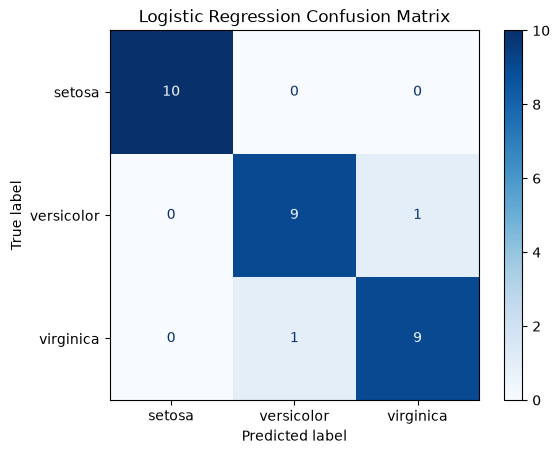

In [14]:
logistic_cm = confusion_matrix(
    y_test_classification,
    logistic_predictions
)

display_logistic = ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=iris.target_names
)

display_logistic.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.show()

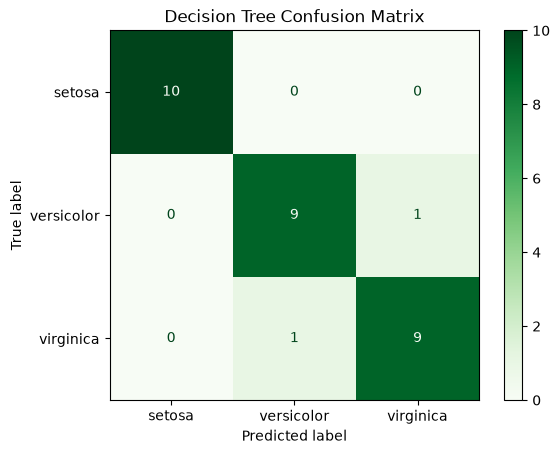

In [15]:
tree_cm = confusion_matrix(
    y_test_classification,
    tree_predictions
)

display_tree = ConfusionMatrixDisplay(
    confusion_matrix=tree_cm,
    display_labels=iris.target_names
)

display_tree.plot(cmap="Greens")

plt.title("Decision Tree Confusion Matrix")
plt.show()

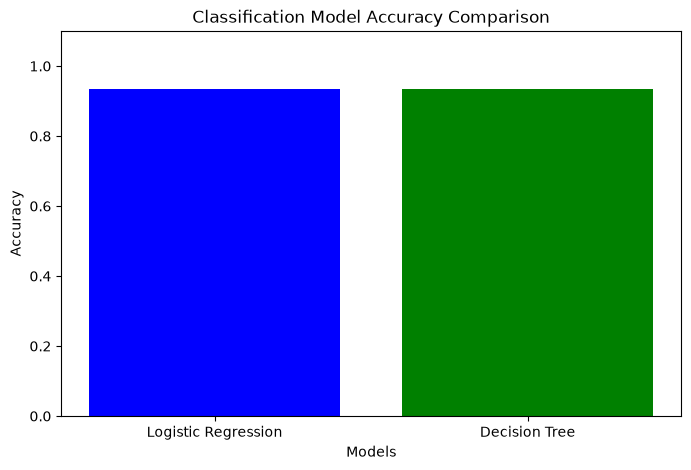

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(
    classification_comparison["Model"],
    classification_comparison["Accuracy"],
    color=["blue", "green"]
)

plt.title("Classification Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)

plt.show()

In [17]:
student_data = {
    "Hours_Studied": [
        1, 2, 3, 4, 5, 6, 7, 8, 2.5, 3.5,
        4.5, 5.5, 6.5, 7.5, 8.5, 1.5, 2.2,
        3.2, 4.2, 5.2, 6.2, 7.2, 8.2, 9, 9.5
    ],
    "Marks": [
        35, 40, 45, 50, 55, 60, 65, 70, 42, 47,
        52, 57, 62, 67, 72, 38, 41, 46, 51, 56,
        61, 66, 71, 75, 78
    ]
}

df_regression = pd.DataFrame(student_data)

df_regression.head()

,Hours_Studied,Marks
0,1.0,35
1,2.0,40
2,3.0,45
3,4.0,50
4,5.0,55


In [18]:
X_regression = df_regression[["Hours_Studied"]]
y_regression = df_regression["Marks"]

X_train_regression, X_test_regression, y_train_regression, y_test_regression = train_test_split(
    X_regression,
    y_regression,
    test_size=0.20,
    random_state=42
)

print("Regression training data shape:", X_train_regression.shape)
print("Regression testing data shape:", X_test_regression.shape)

Regression training data shape: (20, 1)
Regression testing data shape: (5, 1)


In [19]:
linear_model = LinearRegression()

linear_model.fit(X_train_regression, y_train_regression)

regression_predictions = linear_model.predict(X_test_regression)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [20]:
mae = mean_absolute_error(
    y_test_regression,
    regression_predictions
)

mse = mean_squared_error(
    y_test_regression,
    regression_predictions
)

rmse = mse ** 0.5

r2 = r2_score(
    y_test_regression,
    regression_predictions
)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 0.2110749450315069
MSE: 0.08364127190605233
RMSE: 0.2892080080254562
R² Score: 0.9995994191958523


In [21]:
regression_comparison = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae],
    "MSE": [mse],
    "RMSE": [rmse],
    "R² Score": [r2]
})

regression_comparison

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,0.211075,0.083641,0.289208,0.999599


In [22]:
prediction_results = pd.DataFrame({
    "Hours Studied": X_test_regression["Hours_Studied"].values,
    "Actual Marks": y_test_regression.values,
    "Predicted Marks": regression_predictions
})

prediction_results

,Hours Studied,Actual Marks,Predicted Marks
0,2.5,42,42.469616
1,2.2,41,40.974026
2,1.0,35,34.991667
3,9.0,75,74.874062
4,5.5,57,57.425515


In [24]:
if logistic_accuracy == tree_accuracy:
    print("Classification: Both models tied at", logistic_accuracy * 100, "% accuracy.")
    print("Decision Tree offers easier interpretability; Logistic Regression")
    print("often generalizes better on larger datasets.")
else:
    best_model = classification_comparison.loc[classification_comparison["Accuracy"].idxmax(), "Model"]
    print("Best classification model:", best_model)

Classification: Both models tied at 93.33333333333333 % accuracy.
Decision Tree offers easier interpretability; Logistic Regression
often generalizes better on larger datasets.


In [25]:
print("\n--- Analysis ---")
print("Classification: Logistic Regression and Decision Tree performed identically")
print("on this dataset (93.33% accuracy each), since the Iris dataset is small and")
print("well-separated, making it easy for both simple models to perform well.")
print("I would select Decision Tree for this use case since it's easier to visualize")
print("and explain to non-technical stakeholders, while performing equally well.")

print("\nRegression: Linear Regression achieved a very high R² score (0.9996), but this")
print("is because the sample dataset was constructed with a near-perfect linear")
print("relationship between hours studied and marks. Real-world data would likely")
print("show more variation due to other influencing factors.")

print("\nLimitations: Both the classification and regression datasets are small and,")
print("in the case of regression, artificially clean. Results may not generalize well")
print("to larger, noisier, real-world datasets.")


--- Analysis ---
Classification: Logistic Regression and Decision Tree performed identically
on this dataset (93.33% accuracy each), since the Iris dataset is small and
well-separated, making it easy for both simple models to perform well.
I would select Decision Tree for this use case since it's easier to visualize
and explain to non-technical stakeholders, while performing equally well.

Regression: Linear Regression achieved a very high R² score (0.9996), but this
is because the sample dataset was constructed with a near-perfect linear
relationship between hours studied and marks. Real-world data would likely
show more variation due to other influencing factors.

Limitations: Both the classification and regression datasets are small and,
in the case of regression, artificially clean. Results may not generalize well
to larger, noisier, real-world datasets.
